In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.cluster import AgglomerativeClustering

In [3]:
import zipfile
import os

zip_path = "archive.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [4]:
import os

print(os.listdir(extract_path))

['Mall_Customers.csv']


In [5]:
file_path = extract_path + "/Mall_Customers.csv"

df = pd.read_csv(file_path)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# Total rows aur columns check karne ke liye

df.shape

(200, 5)

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

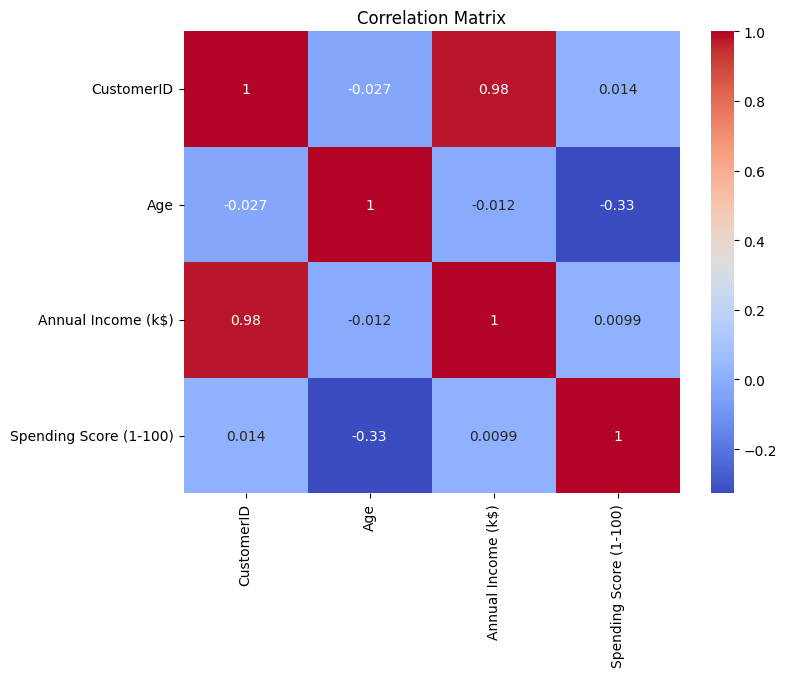

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(

    numeric_df.corr(),

    annot=True,

    cmap='coolwarm'

)

plt.title("Correlation Matrix")

plt.show()

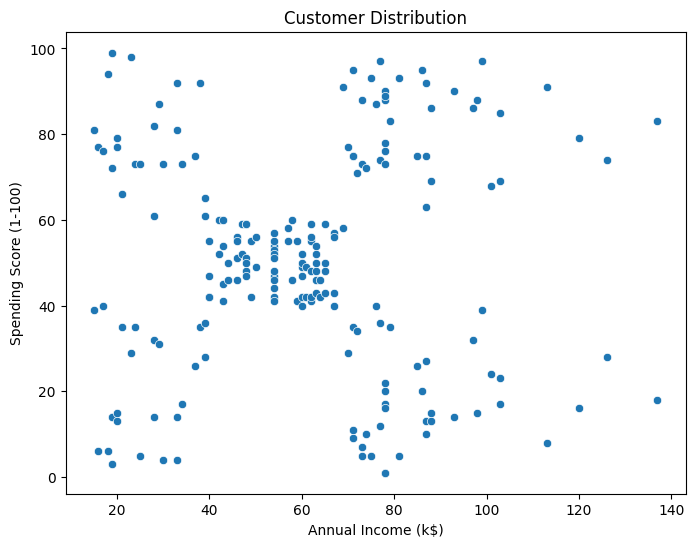

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x='Annual Income (k$)',

    y='Spending Score (1-100)'

)

plt.title("Customer Distribution")

plt.show()

In [16]:
# Sirf Income aur Spending Score select kar rahe hain

X = df[['Annual Income (k$)',

        'Spending Score (1-100)']]

In [17]:
# StandardScaler object create kar rahe hain

scaler = StandardScaler()

# Dataset ko scale kar rahe hain

X_scaled = scaler.fit_transform(X)

In [18]:
print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [19]:
# Dendrogram banane ke liye
from scipy.cluster.hierarchy import dendrogram, linkage

# Actual Hierarchical Clustering Algorithm
from sklearn.cluster import AgglomerativeClustering

In [20]:
# Ward linkage use kar rahe hain
linkage_matrix = linkage(

    X_scaled,          # Scaled data

    method='ward'      # Ward Linkage

)

In [21]:
print(linkage_matrix[:5])

[[6.50000000e+01 6.80000000e+01 0.00000000e+00 2.00000000e+00]
 [4.80000000e+01 4.90000000e+01 0.00000000e+00 2.00000000e+00]
 [1.56000000e+02 1.58000000e+02 0.00000000e+00 2.00000000e+00]
 [1.29000000e+02 1.31000000e+02 0.00000000e+00 2.00000000e+00]
 [1.70000000e+02 1.74000000e+02 3.81694292e-02 2.00000000e+00]]


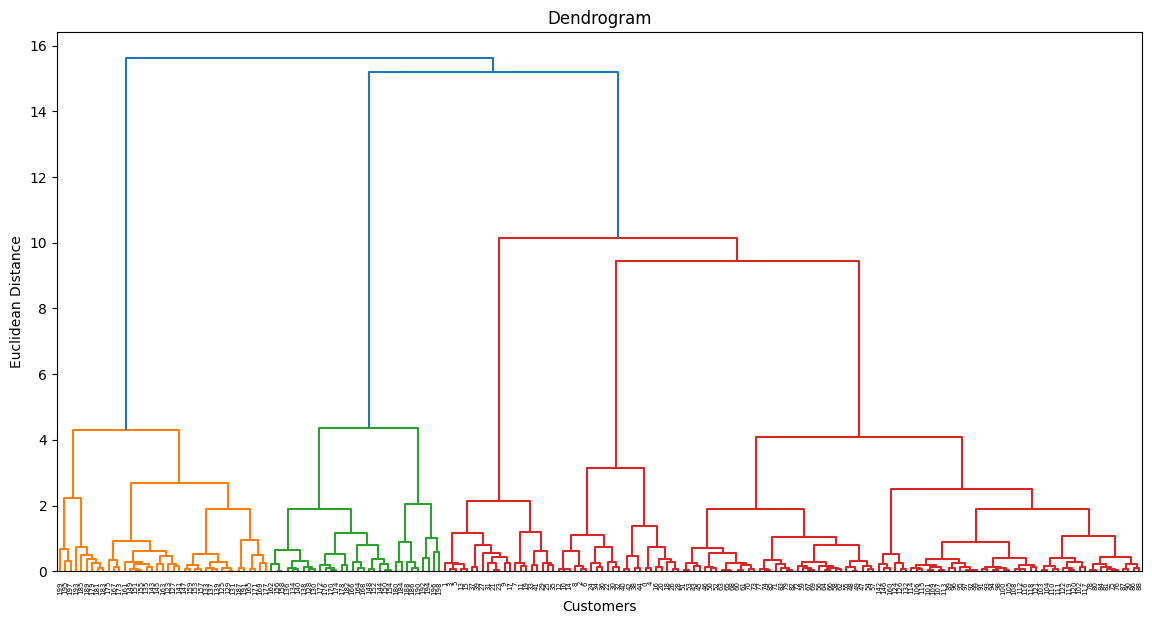

In [22]:
# ============================================
# Step 18 : Plot Dendrogram
# ============================================

plt.figure(figsize=(14,7))

# Dendrogram draw kar rahe hain
dendrogram(

    linkage_matrix

)

plt.title("Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")

plt.show()

In [23]:
# ============================================
# Step 20 : Create Hierarchical Model
# ============================================

# Agglomerative Clustering object create kar rahe hain

hc = AgglomerativeClustering(

    n_clusters=5,      # Dendrogram se choose kiya hua number of clusters

    metric='euclidean',# Distance calculate karne ka method

    linkage='ward'     # Ward linkage (most commonly used)

)

In [24]:
clusters = hc.fit_predict(X_scaled)

In [25]:
print(clusters[:10])

[4 3 4 3 4 3 4 3 4 3]


In [26]:
# Dataset me naya column add kar rahe hain

df['Cluster'] = clusters

In [27]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


In [28]:
# Har cluster me kitne customers hain

df['Cluster'].value_counts()

,count
Cluster,
2,85
1,39
0,32
4,23
3,21


In [29]:
# Har cluster ki average values

df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,166.250000,41.000000,89.406250,15.593750
1,162.000000,32.692308,86.538462,82.128205
2,87.894118,42.482353,55.811765,49.129412
3,22.000000,25.333333,25.095238,80.047619
4,23.000000,45.217391,26.304348,20.913043


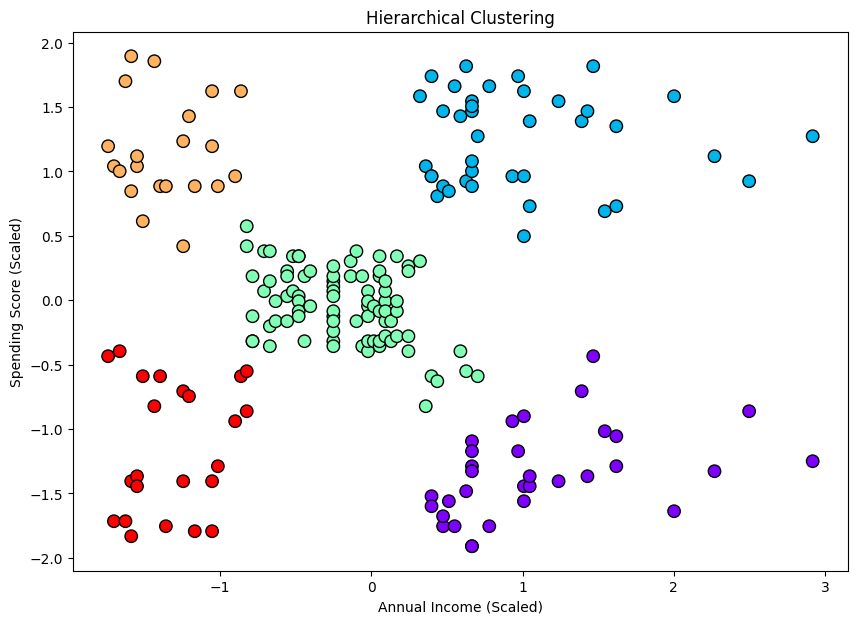

In [30]:
# ============================================
# Step 27 : Visualize Clusters
# ============================================

plt.figure(figsize=(10,7))

# Scatter plot
plt.scatter(

    X_scaled[:,0],            # Annual Income

    X_scaled[:,1],            # Spending Score

    c=clusters,               # Cluster ke hisaab se colour

    cmap='rainbow',           # Colour map

    s=80,                     # Dot size

    edgecolor='black'         # Border

)

plt.title("Hierarchical Clustering")

plt.xlabel("Annual Income (Scaled)")

plt.ylabel("Spending Score (Scaled)")

plt.show()